In [67]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = sio.loadmat(r"D:\LabBiosenales\signals.mat")
data
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])

In [ ]:
# Implementación de funciones

def RMS_value(signal):
    return np.sqrt(np.mean(signal**2))

# Análisis estadístico de las señal ECG

In [90]:
# Tiempo de la señal
num_muestras = data['ECG_filtered'].shape[1]
Ts = 1/data['Fs'] 
t = num_muestras * Ts 
T = np.arange(0, t, Ts) # Vector de tiempo
print(f"Tiempo total de la señal: {t} segundos")


Tiempo total de la señal: [[30.]] segundos


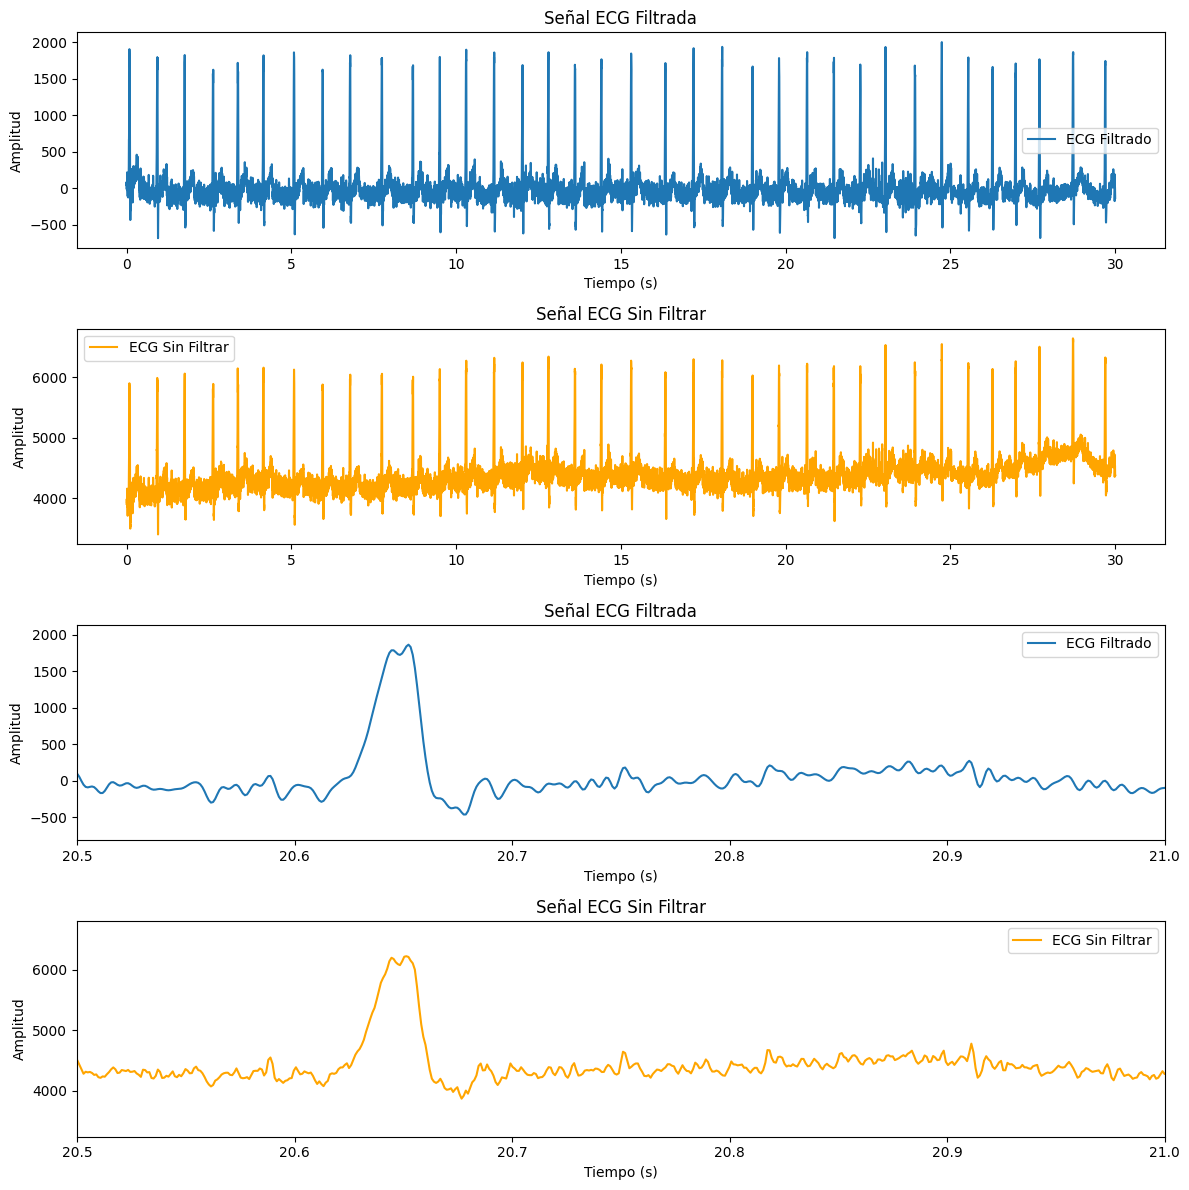

In [91]:
# Gráfica de la señal ECG filtrada y sin filtrar
plt.figure(figsize=(12, 12))
plt.subplot(4, 1, 1)
plt.plot(T, data['ECG_filtered'][0], label='ECG Filtrado')
plt.title('Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud') 
plt.legend()
plt.subplot(4, 1, 2)
plt.plot(T, data['ECG_asRecording'][0], label='ECG Sin Filtrar', color='orange')
plt.title('Señal ECG Sin Filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.subplot(4, 1, 3)
plt.plot(T, data['ECG_filtered'][0], label='ECG Filtrado')
plt.xlim(20.5, 21) 
plt.title('Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud') 
plt.legend()
plt.subplot(4, 1, 4)
plt.plot(T, data['ECG_asRecording'][0], label='ECG Sin Filtrar', color='orange')
plt.xlim(20.5, 21)
plt.title('Señal ECG Sin Filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.tight_layout()

- En la señal sin filtro se observa una tendencia de la señal a crear un tipo de rampa, esto se atribuye bajas frecuencias, siendo más notorias entre los segundos 20 y 30. Para la aliminación de estas se aplica un filtro pasa altas que deje por fuera estas señales, al aplicarlo se evidencia la eliminación de estas curvas amplias, aplanando un poco la señal, como se observa en la señal filtrada.
- Se nota también que el offset de la señal sin filtrar está alrededor de los 4000 o 4500 y la filtrada se centrada en cero.
- El rango de interés de la señal ECG es de 0.05 Hz a 100 Hz. Si se aplica un filtrp pasabandas en ese rango, será necesario aplicar un filtro Notch para eliminar el ruido de 60 Hz de la red eléctrica, en la gráfica acotada en 0.5 segundos se puede notar que la oscilaciones rápidas desaperecen un poco, en la señal filtrada presenta un trazo un poco más limpio.

Análisis del ciclo cardíaco sin filtrar:
Valor RMS: 4160.8849
Valor promedio: 4144.5206
Valor de la varianza: 135912.2605
Valor de la desviación estándar: 368.6628


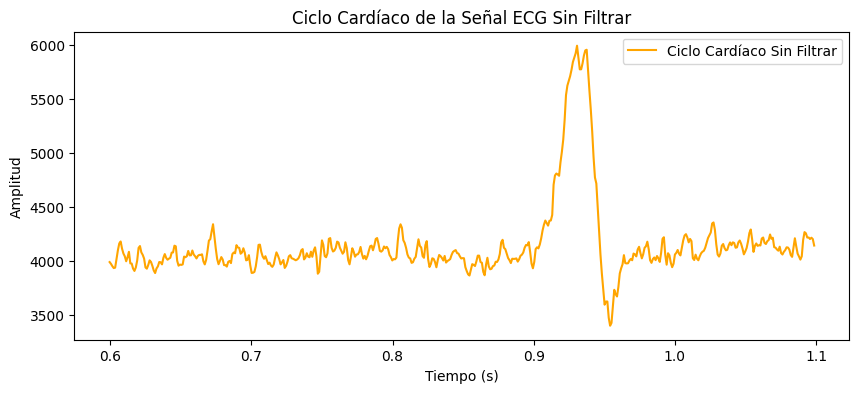

In [124]:
# Análisis de un único ciclo cardíaco de la señal sin filtrar

t_inicio = 0.6
t_fin = 1.1

idx_inicio = int(t_inicio / Ts)
idx_fin = int(t_fin / Ts)
ciclo = data['ECG_asRecording'][0][idx_inicio:idx_fin]
T_ciclo = T[idx_inicio:idx_fin]

plt.figure(figsize=(10, 4))
plt.plot(T_ciclo, ciclo, label='Ciclo Cardíaco Sin Filtrar', color='orange')
plt.title('Ciclo Cardíaco de la Señal ECG Sin Filtrar')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()


# Cálculo del valor RMS del ciclo cardíaco sin filtrar
print("Análisis del ciclo cardíaco sin filtrar:")
rms= RMS_value(ciclo)
print(f"Valor RMS: {rms:.4f}")
promedio= np.mean(ciclo)
print(f"Valor promedio: {promedio:.4f}")
var = np.var(ciclo)
print(f"Valor de la varianza: {var:.4f}") 
std = np.std(ciclo)
print(f"Valor de la desviación estándar: {std:.4f}")

Análisis del ciclo cardíaco filtrado:
Valor RMS: 362.4985
Valor promedio: 9.3836
Valor de la varianza: 131317.1197
Valor de la desviación estándar: 362.3770


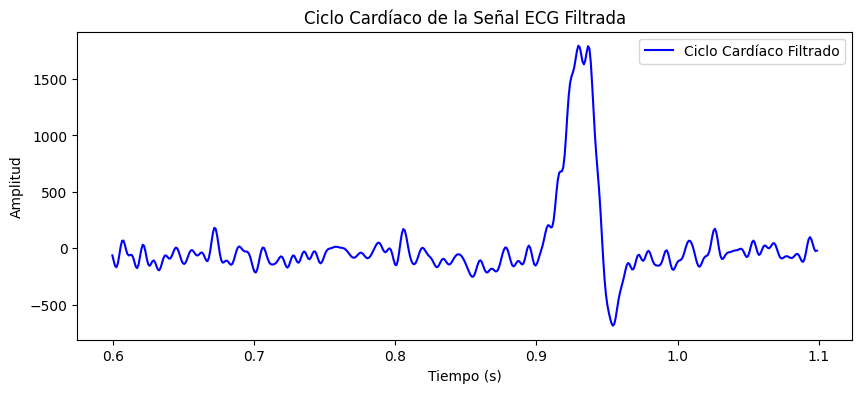

In [123]:
t_inicio = 0.6
t_fin = 1.1

idx_inicio = int(t_inicio / Ts)
idx_fin = int(t_fin / Ts)
ciclo_ = data['ECG_filtered'][0][idx_inicio:idx_fin]
T_ciclo = T[idx_inicio:idx_fin]

plt.figure(figsize=(10, 4))
plt.plot(T_ciclo, ciclo_, label='Ciclo Cardíaco Filtrado', color='blue')
plt.title('Ciclo Cardíaco de la Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()


# Cálculo del valor RMS del ciclo cardíaco filtrado
print("Análisis del ciclo cardíaco filtrado:")
rms_ = RMS_value(ciclo_)
print(f"Valor RMS: {rms_:.4f}")
promedio_ = np.mean(ciclo_)
print(f"Valor promedio: {promedio_:.4f}")
var_ = np.var(ciclo_)
print(f"Valor de la varianza: {var_:.4f}") 
std_ = np.std(ciclo_)
print(f"Valor de la desviación estándar: {std_:.4f}")

- Se observa un cambio notorio en los resultados obtenidos para cada segmento de señal, especialmente en el promedio que se ve seriamente afectado por la ubicación general debido al voltaje de offset de la señal sin filtrar, esto da una representación numperica de la utilidad del filtro de paso de banda.
- En los resultados de la señal sin filtrar se observa una diferencia significativa entre el valor RMS y la desviación estandar de la señal, de nuevo, afectado por la ubicacipon general de la señal. En cambio, en la señal filtrada notamos que estos dos valores son casi idénticos, lo que da cuenta de que la media de la señal es muy cercana a cero en ese caso.
- En cuanto a la varianza y la desviación estandar, estos valores se mantuvieron relativamente cercanos, esto debido a que miden la oscialción respecto a su centro. El cambio que se ve en la desviación estandar puede reresentar la eliminación del ruido de frecuencias más altas.



Text(0, 0.5, 'Amplitud')

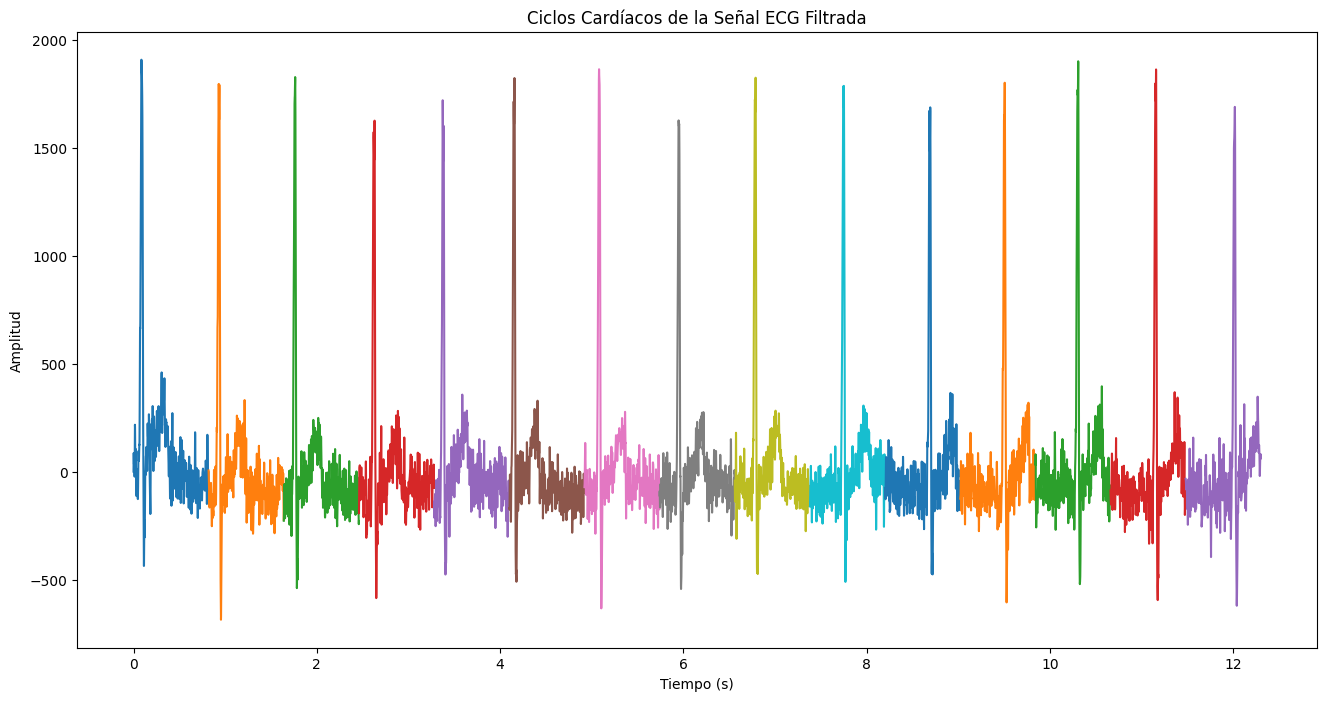

In [125]:
# Análisis de 15 ciclos de la señal ECG filtrada

# t_inicio = 0
# t_fin = 12.5

# idx_inicio = int(t_inicio / Ts)
# idx_fin = int(t_fin / Ts)
# ciclo = data['ECG_filtered'][0][idx_inicio:idx_fin]
# T_ciclo = T[idx_inicio:idx_fin]
# plt.plot(T_ciclo, ciclo, label='Ciclo Cardíaco Filtrado', color='blue')

promedios = []
varianzas = []
periodo_ciclos = 0.82
duracion_ciclo = 0.82

plt.figure(figsize=(16, 8))

for i in range(0, 15):
    t_inicio = i * periodo_ciclos
    t_fin = t_inicio + duracion_ciclo

    idx_inicio = int(t_inicio / Ts)
    idx_fin = int(t_fin / Ts)
    ciclo = data['ECG_filtered'][0][idx_inicio:idx_fin]
    T_ciclo = T[idx_inicio:idx_fin]

    plt.plot(T_ciclo, ciclo)
    
    promedios.append(np.mean(ciclo))
    varianzas.append(np.var(ciclo))

plt.title('Ciclos Cardíacos de la Señal ECG Filtrada')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')

In [126]:
promedios

[np.float64(89.72531476474666),
 np.float64(-7.241253456150445),
 np.float64(-11.900049230023384),
 np.float64(-4.627472546021548),
 np.float64(9.584219083893437),
 np.float64(-6.088529085139393),
 np.float64(10.158209161218847),
 np.float64(2.6217557921751147),
 np.float64(9.656927353818133),
 np.float64(15.851343936535207),
 np.float64(0.4694355333597828),
 np.float64(-4.623871482895863),
 np.float64(12.244476197150178),
 np.float64(-7.705908259903823),
 np.float64(-7.113384884705331)]

In [127]:
varianzas

[np.float64(95395.87984398268),
 np.float64(88449.37401965885),
 np.float64(85308.30639551154),
 np.float64(74239.11678883334),
 np.float64(77346.29627540275),
 np.float64(87190.3769483129),
 np.float64(87994.90084320928),
 np.float64(72902.66617198903),
 np.float64(83870.95785364484),
 np.float64(83634.11516310004),
 np.float64(75647.28573379916),
 np.float64(81355.88479406184),
 np.float64(90039.12626284795),
 np.float64(90632.82649232603),
 np.float64(80529.46248415532)]

NO SABRÍA CONCLUIR SI SON ESTACIONARIAS O NO, HAY CAMBIOS EVIDENTES, PERO NO SÉ SI SIGNIFICATIVOS

In [117]:
import scipy.stats as stats

In [128]:
# Análisis de dos ciclos específicos

ciclo1 = data['ECG_filtered'][0][int((0.82*2) / Ts):int((0.82*3) / Ts)]
stat1, p1 = stats.shapiro(ciclo1)
ciclo2 = data['ECG_filtered'][0][int((0.82*10) / Ts):int((0.82*11) / Ts)]
stat2, p2 = stats.shapiro(ciclo2)

a = 0.05
print(f"Ciclo 1: p-valor={p1:.4f}")
print(f"Ciclo 2: p-valor={p2:.4f}")


Ciclo 1: p-valor=0.0000
Ciclo 2: p-valor=0.0000


In [130]:
n = p1 > a
n

np.False_

## Tiesa y calva mk

No sé qué hacer con ese valor p = cero
